In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import awkward as ak

Path1 = '/raid1/genli/Data_D2O/M1_data/run4123_processed_v3.root'
# Path2 = '/raid1/genli/Data_D2O/M1_data/run4124_processed_v3.root'
# Path3 = '/raid1/genli/Data_D2O/M1_data/run4125_processed_v3.root'



In [2]:
data1 = uproot.open(Path1)['tree']

In [3]:
print("Available branches:")
print(data1.keys())
print("\n" + "="*40)

# Print shapes for first event of each branch
print("First event shapes:")
for branch in data1.keys():
    # Get first event as numpy array
    first_event = ak.to_numpy(data1[branch].array(library='ak')[0])
    
    print(f"  {branch}: {first_event.shape} - dtype: {first_event.dtype}")

Available branches:
['eventID', 'nSamples', 'adcVal', 'baselineMean', 'baselineRMS', 'pulseH', 'area', 'peakPosition', 'nsTime', 'triggerBits']

First event shapes:
  eventID: (1,) - dtype: int32
  nSamples: (32,) - dtype: int32
  adcVal: (32, 45) - dtype: int16
  baselineMean: (32,) - dtype: float64
  baselineRMS: (32,) - dtype: float64
  pulseH: (32,) - dtype: float64
  area: (32,) - dtype: float64
  peakPosition: (32,) - dtype: int32
  nsTime: (1,) - dtype: int64
  triggerBits: (1,) - dtype: int32


Randomly selected event indices: [15795   860  5390 11964 11284  6265 16850  4426 14423 11363 16023  8322
  1685   769  2433  5311  5051  6420 17568 19769  6396  8666 18942 18431
  2747   189 19118  3005  1899  1267 17912 11394  3556  3890  8838 14502
 10627  8792 10555 10253]


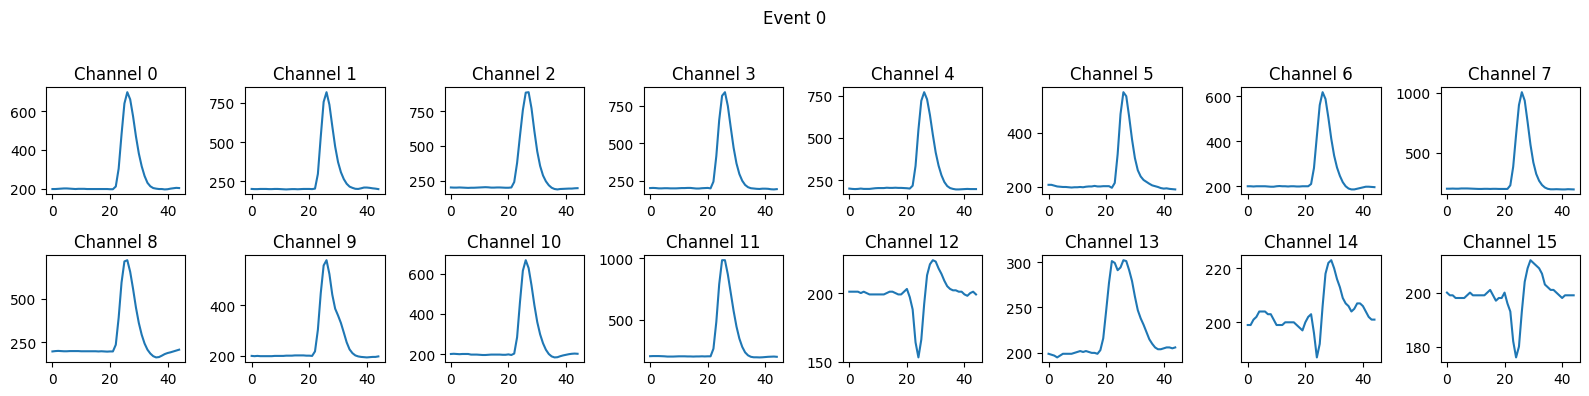

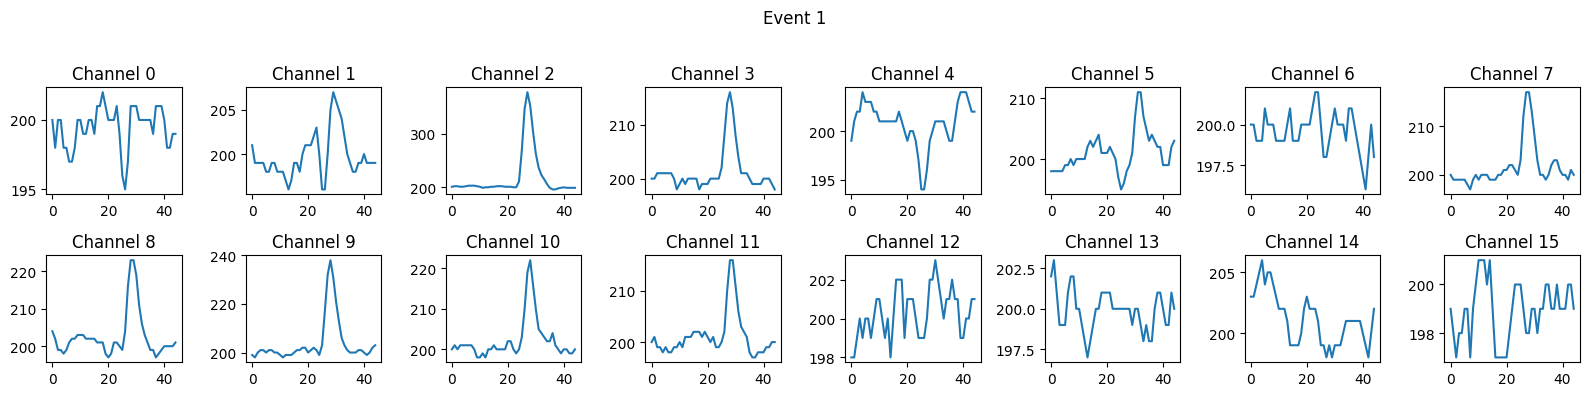

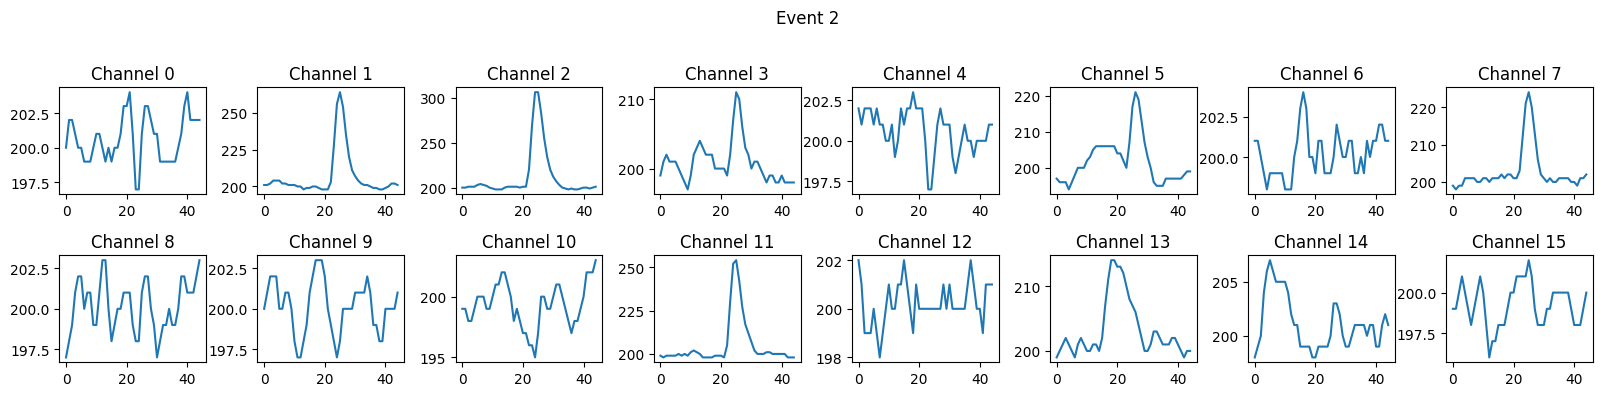

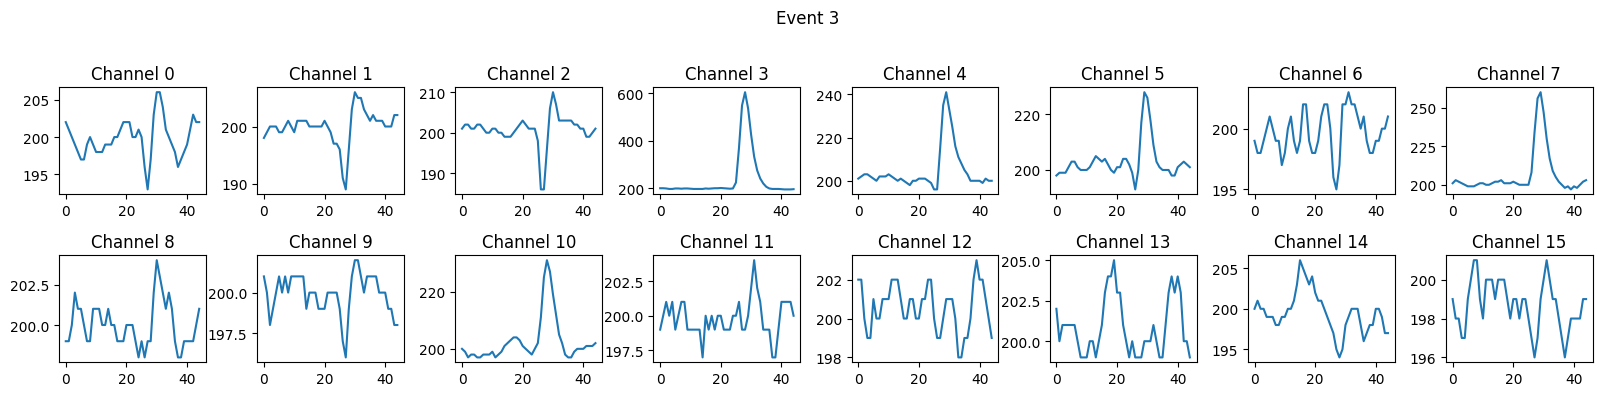

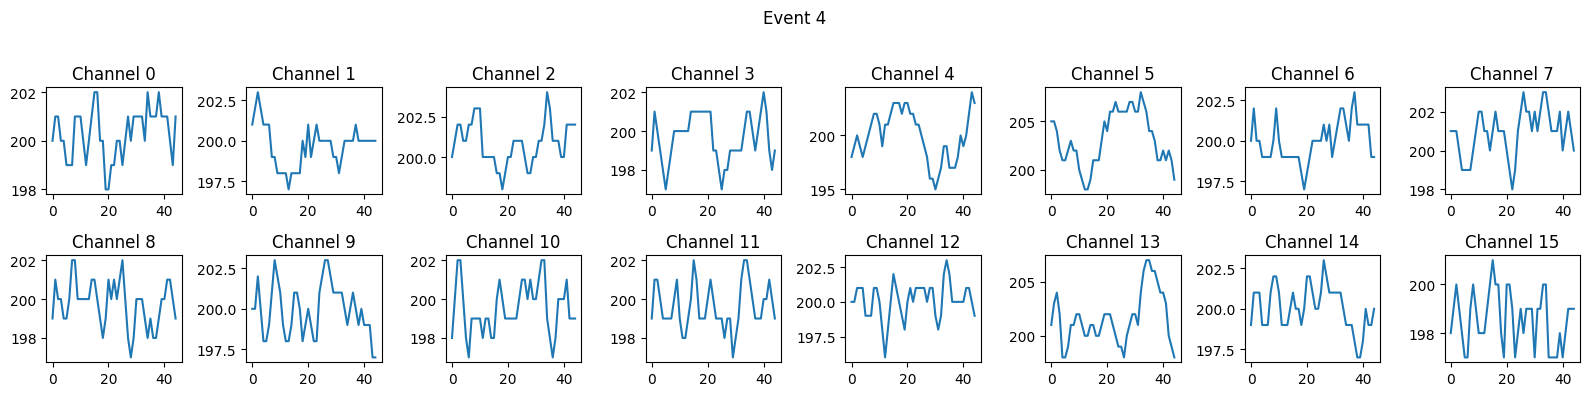

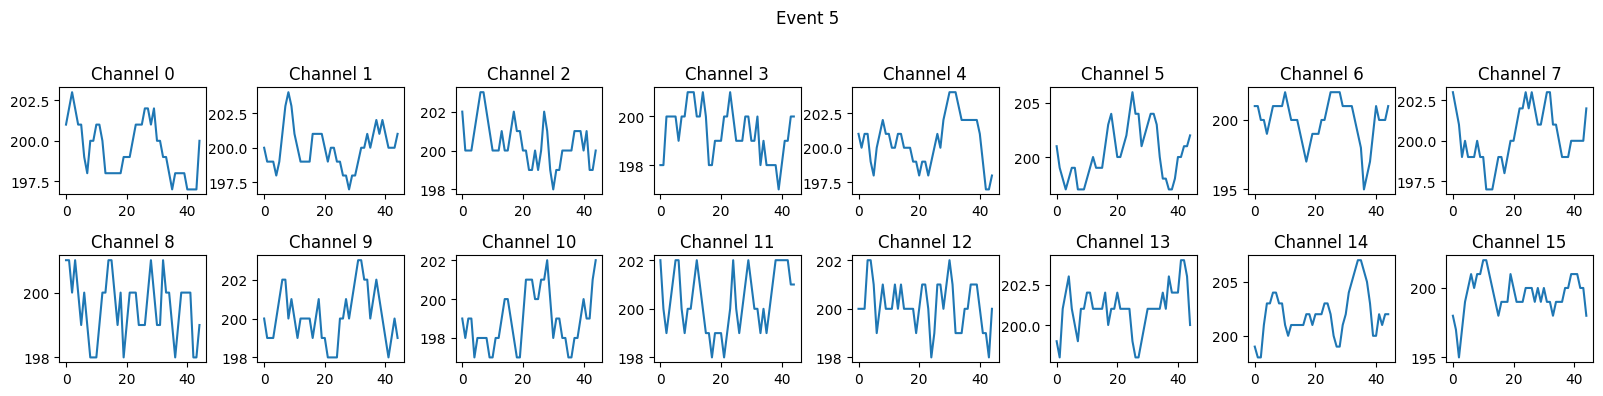

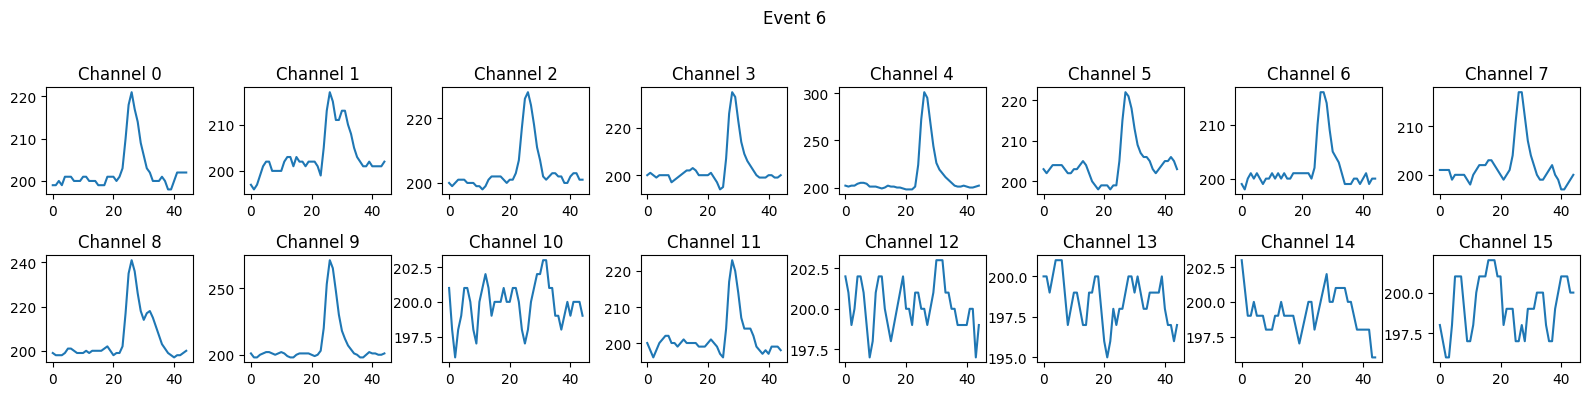

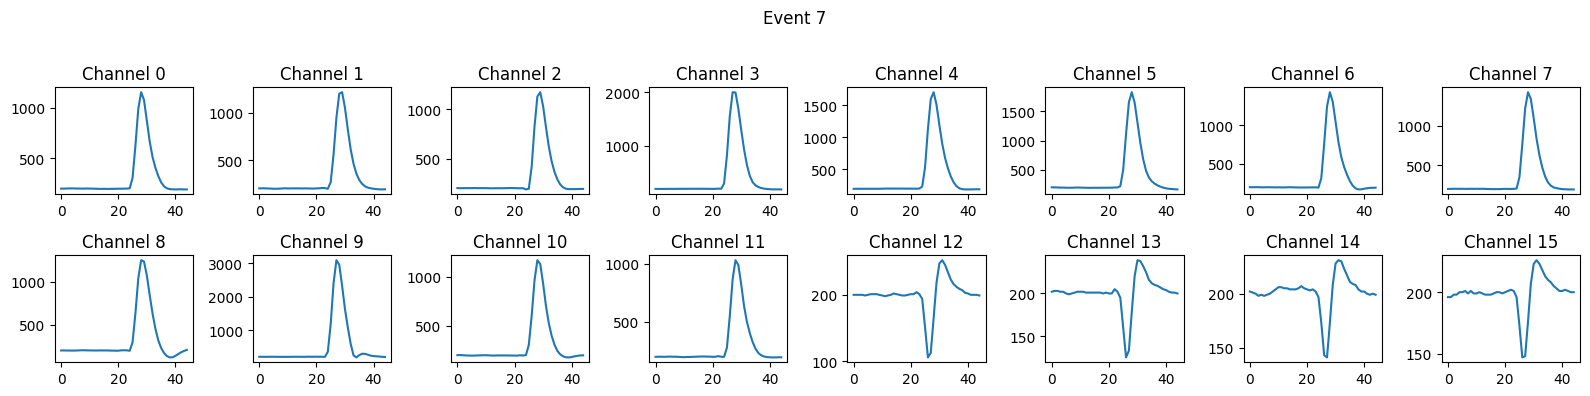

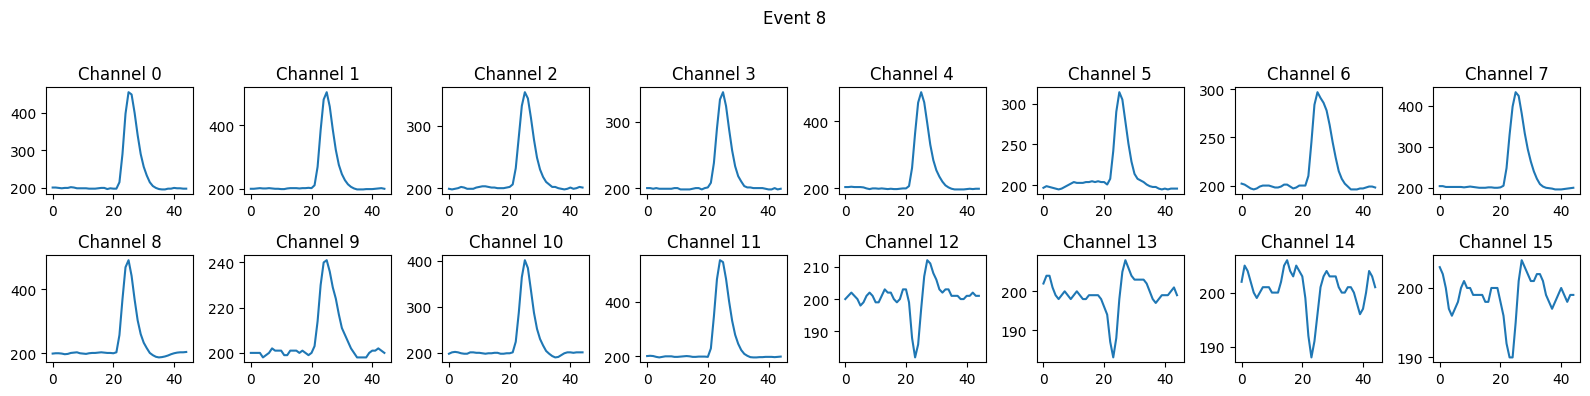

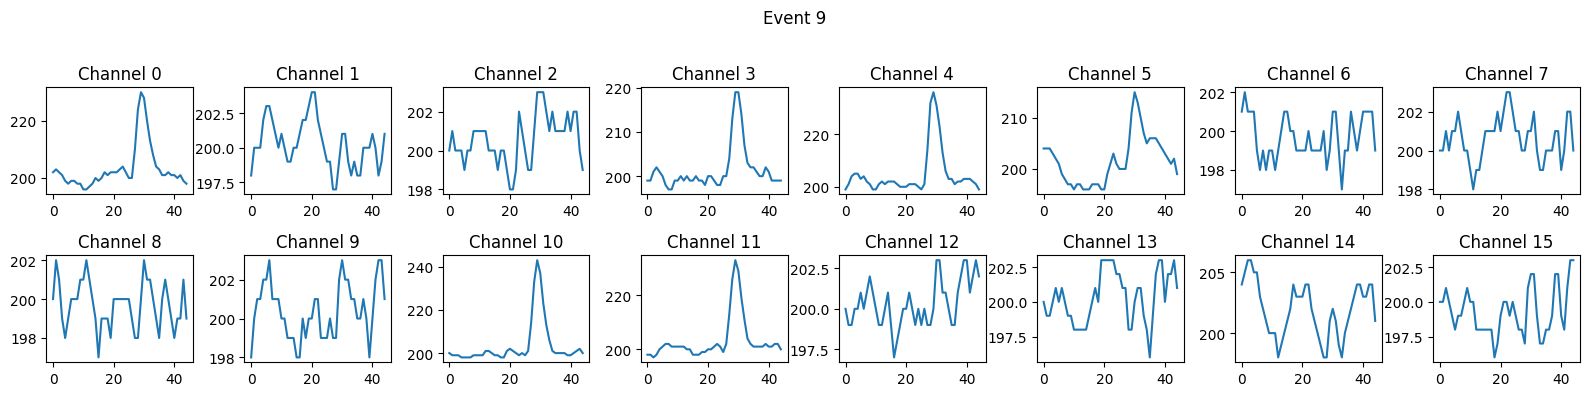

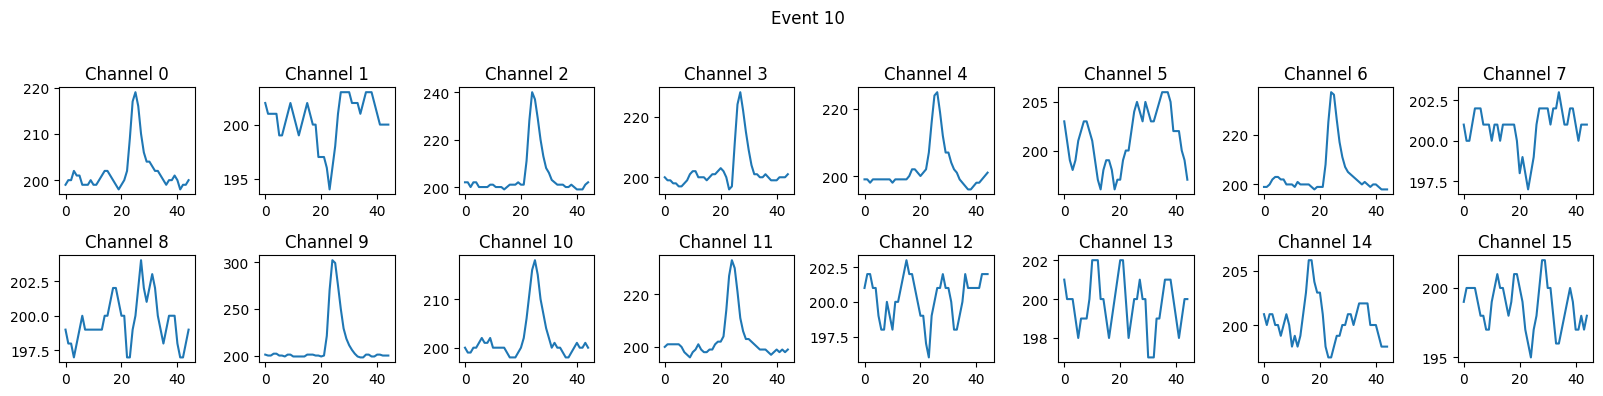

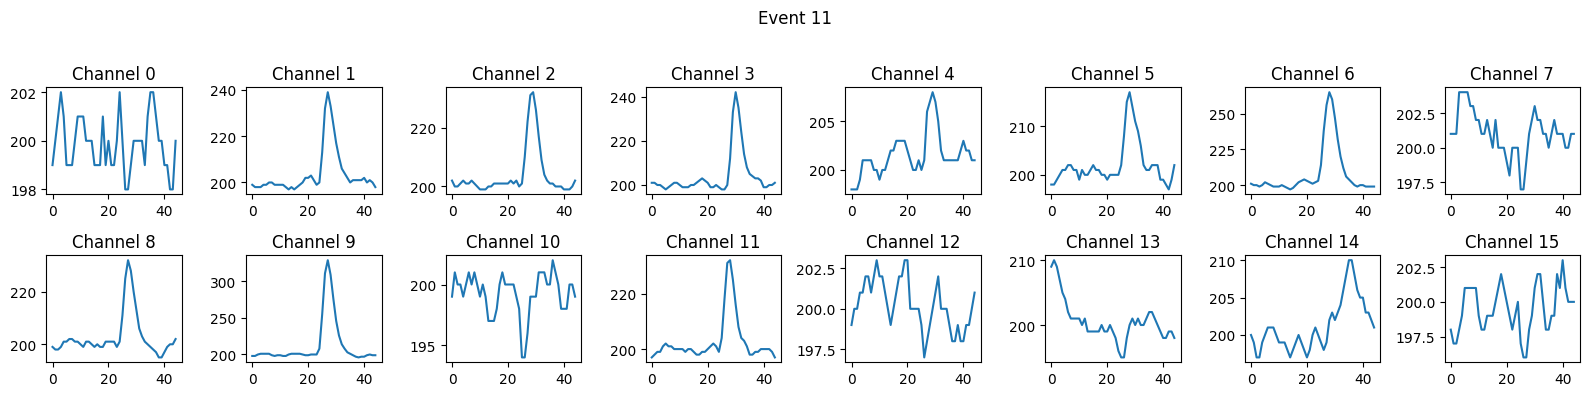

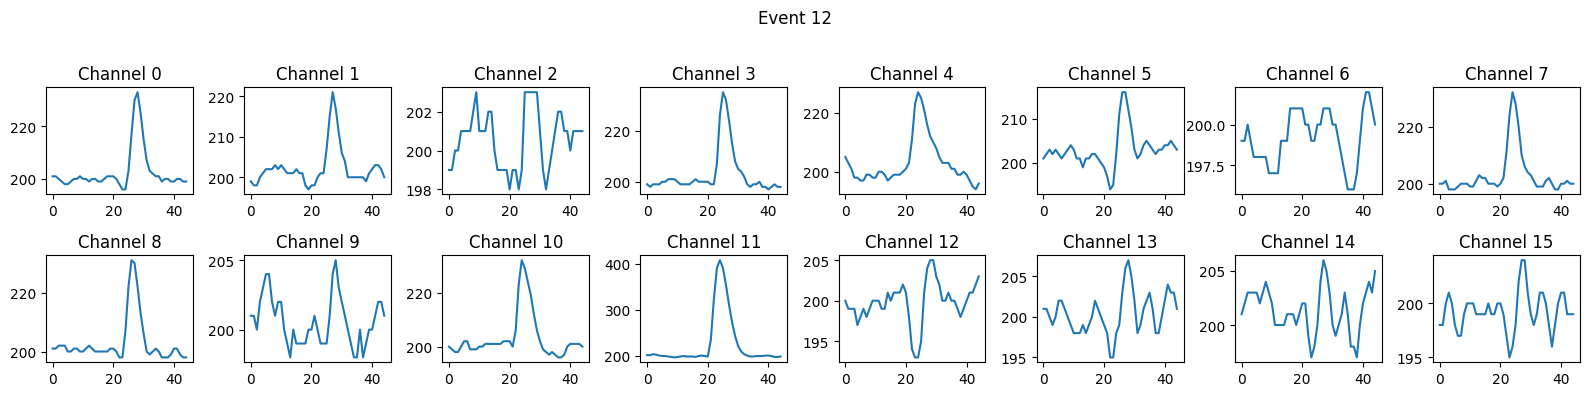

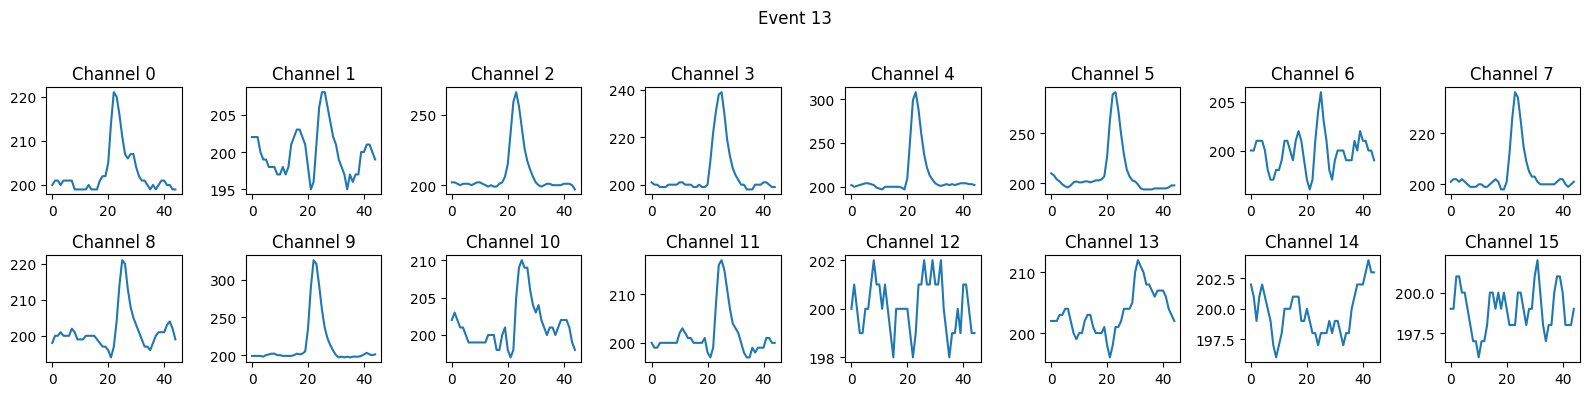

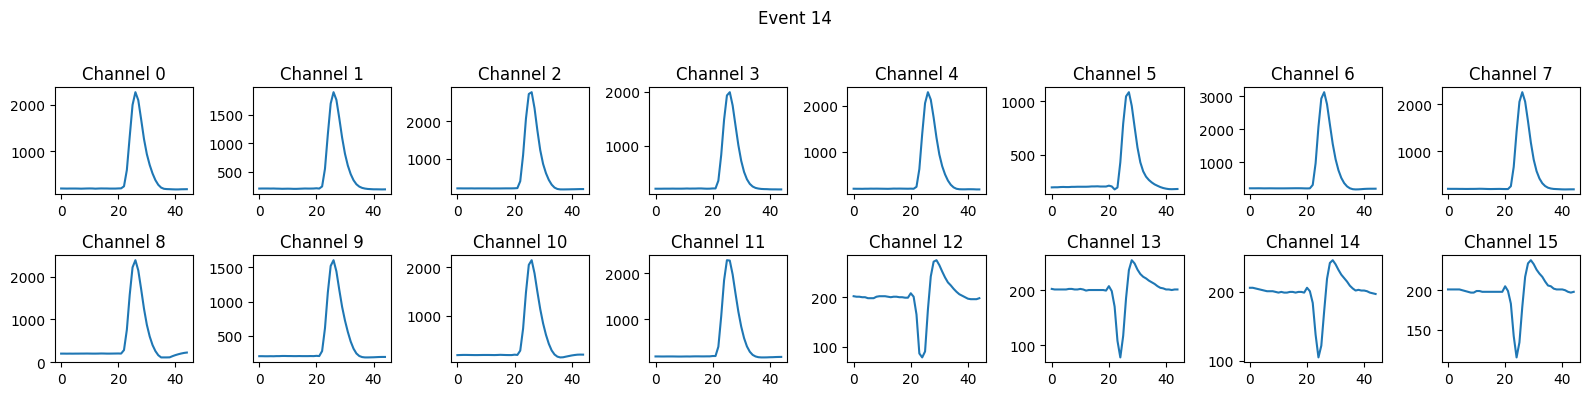

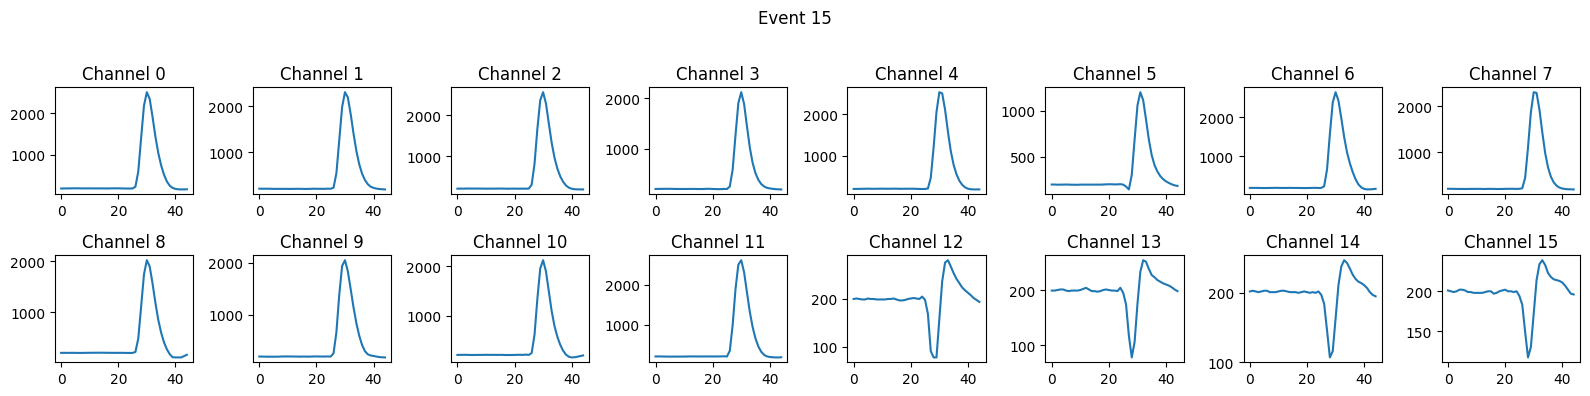

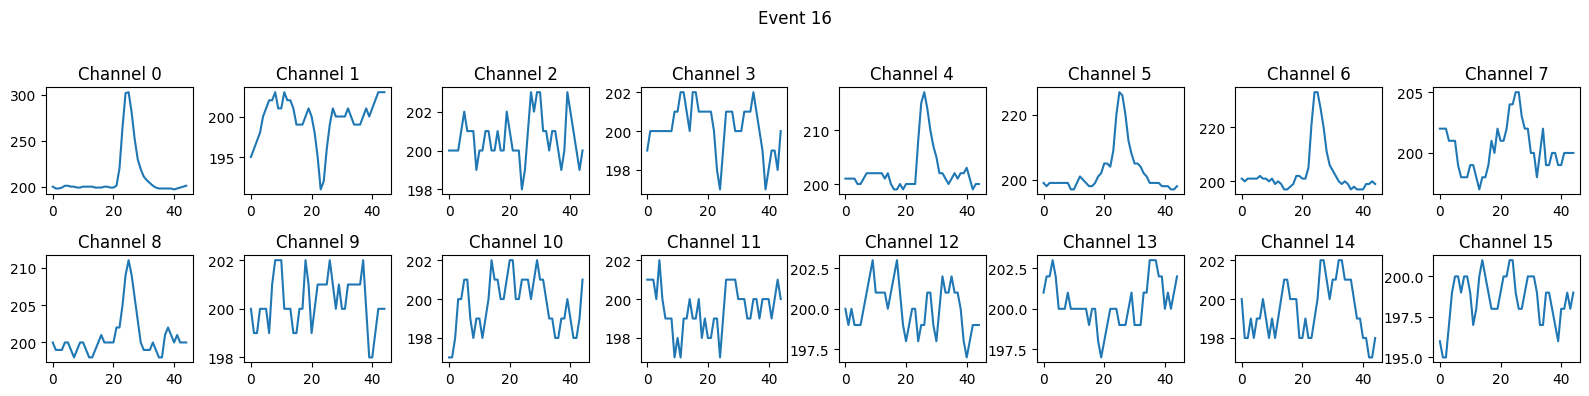

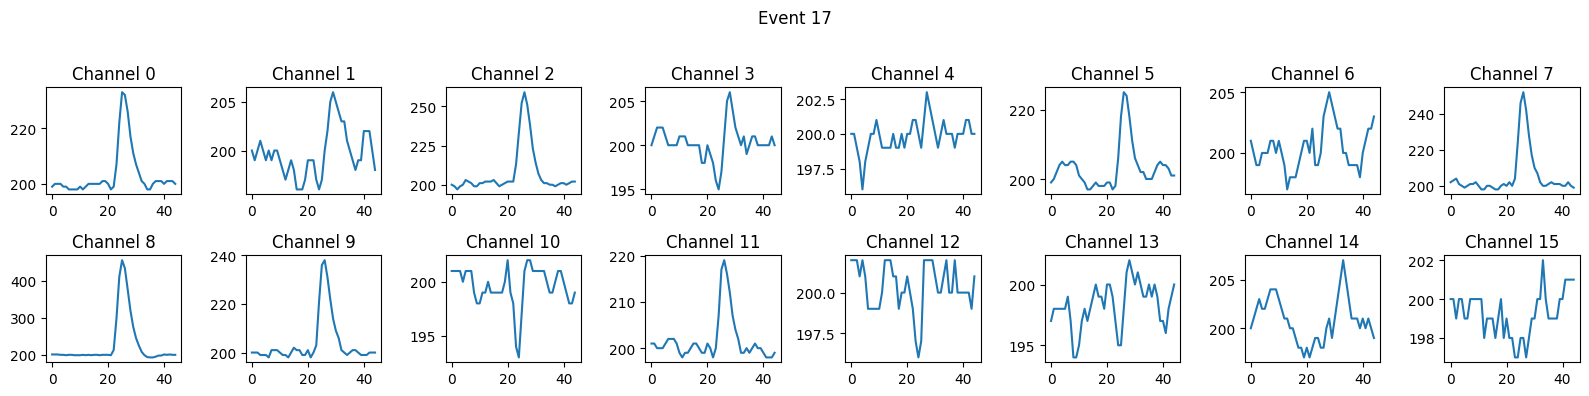

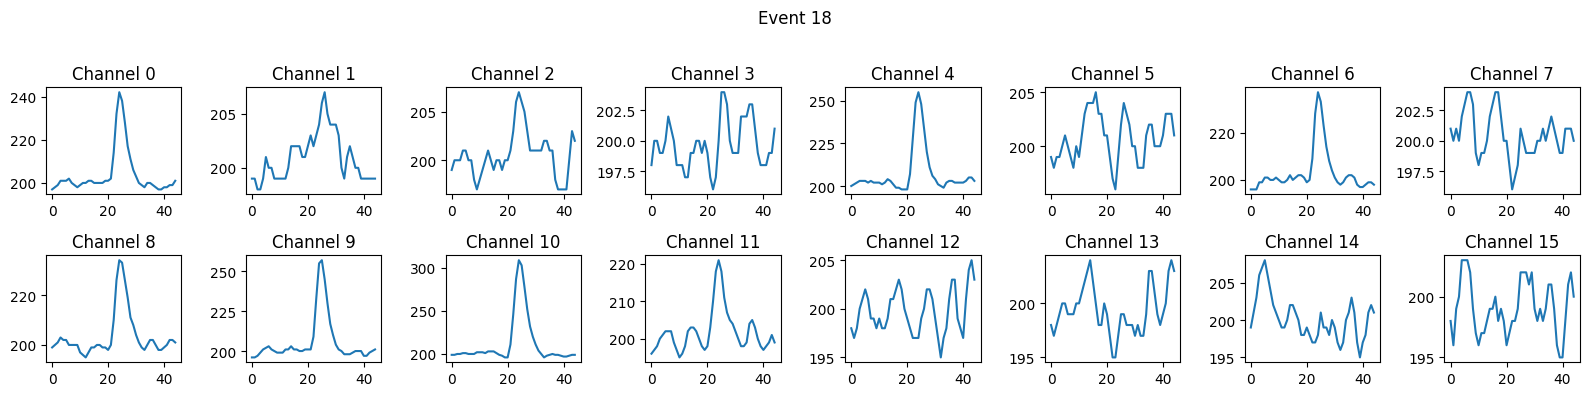

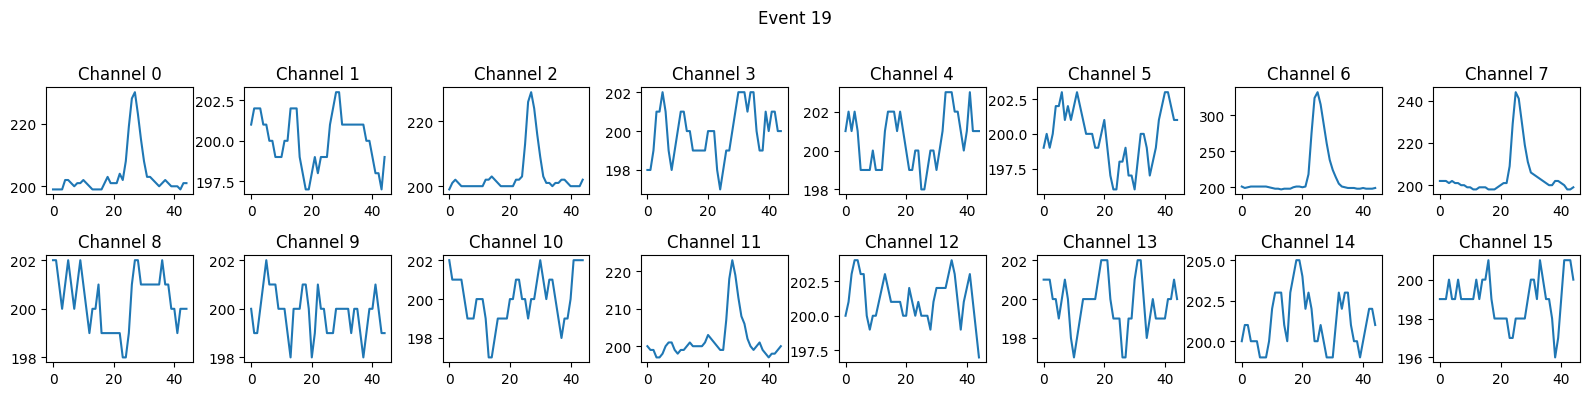

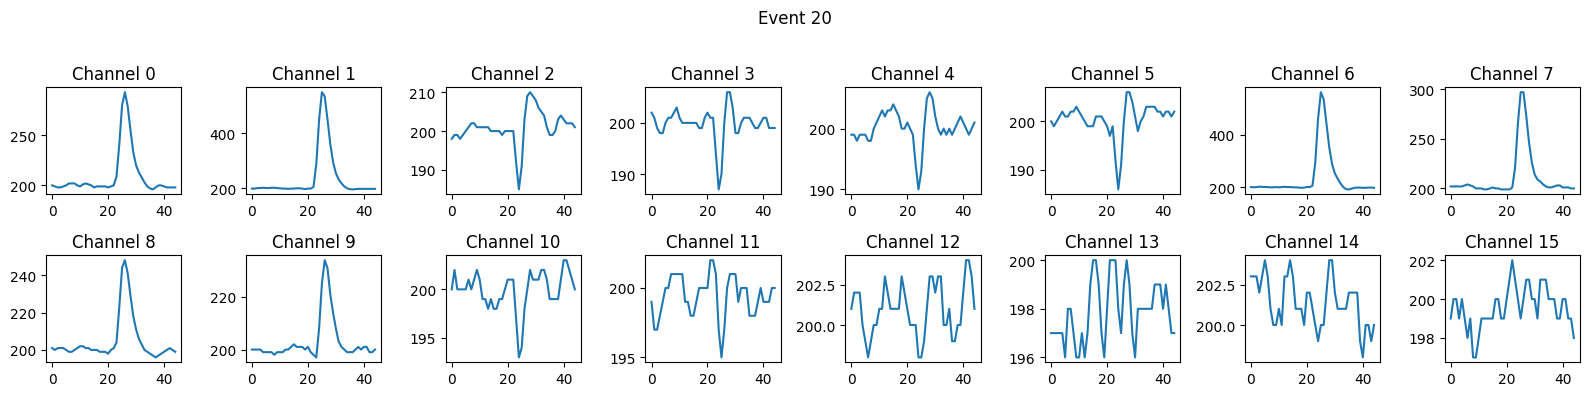

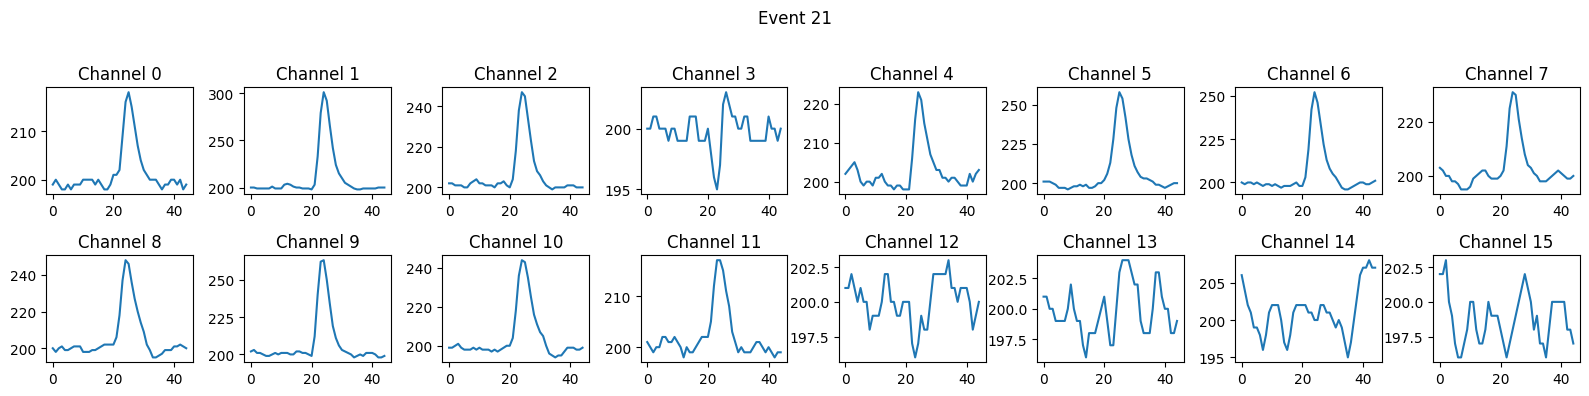

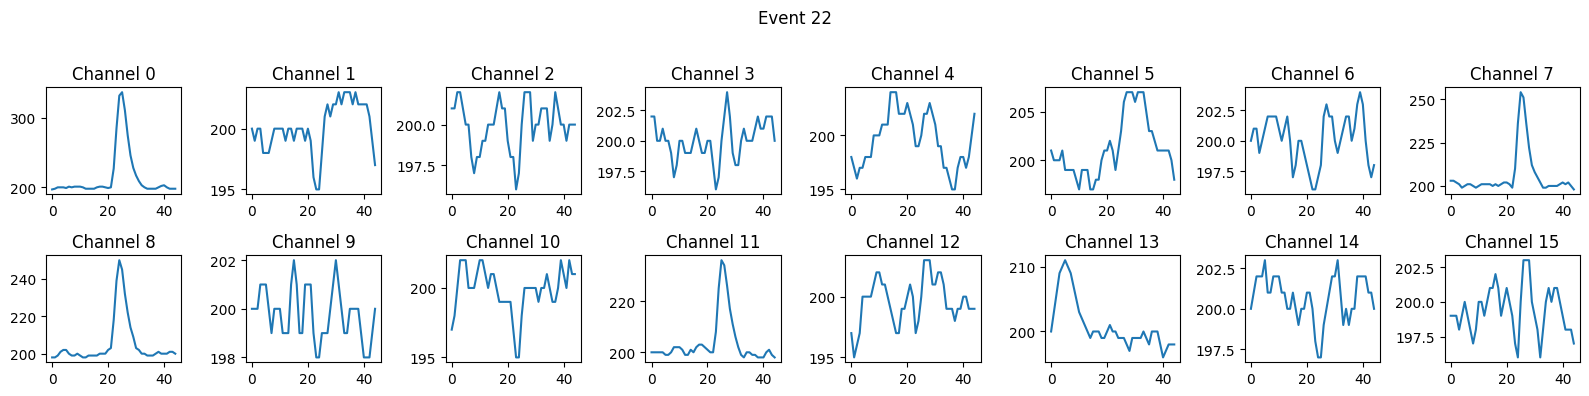

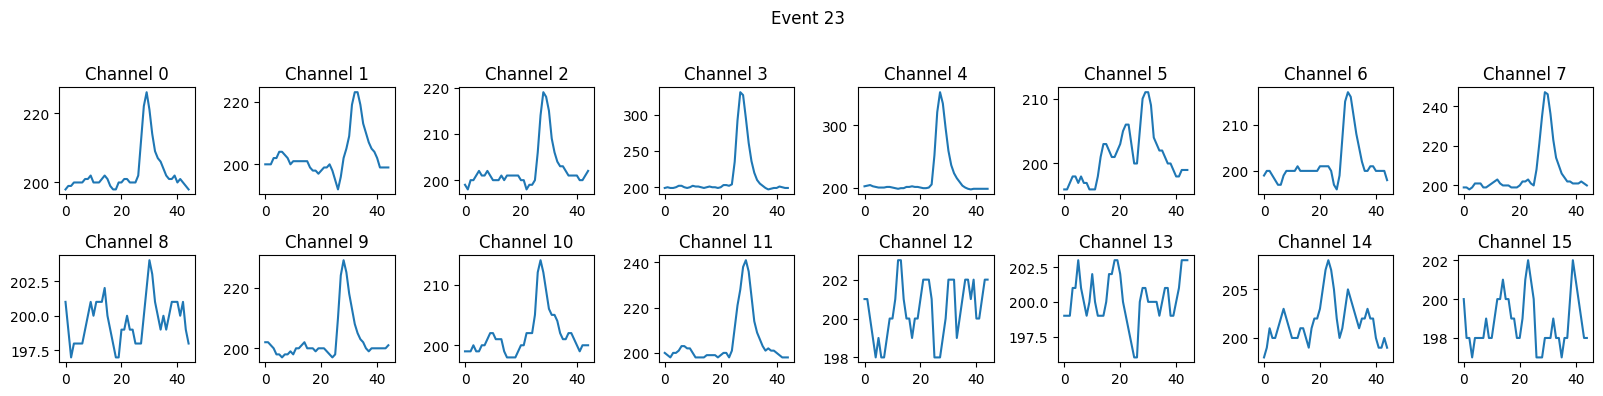

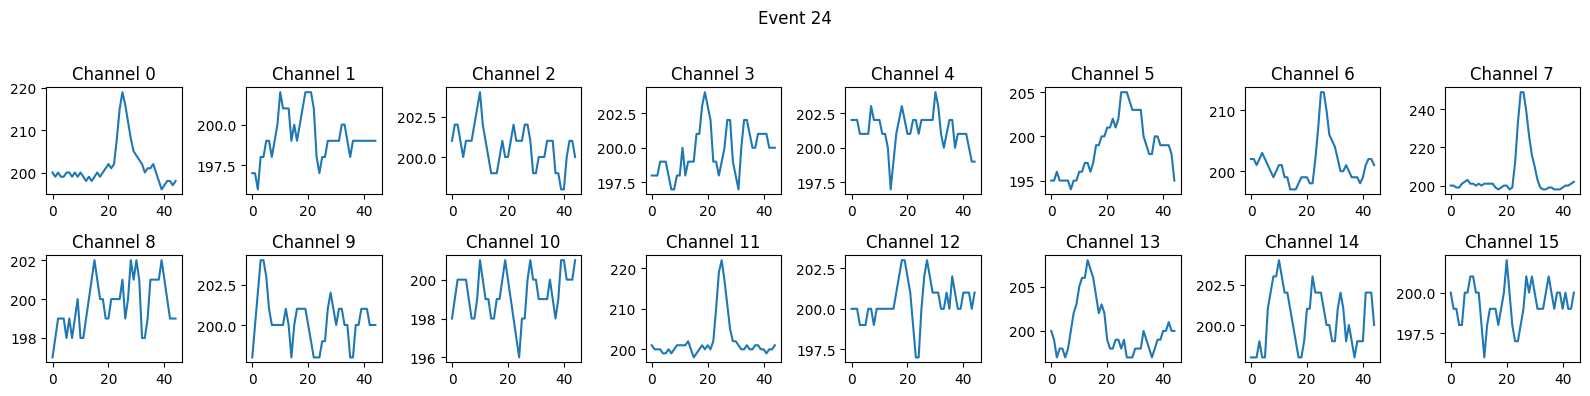

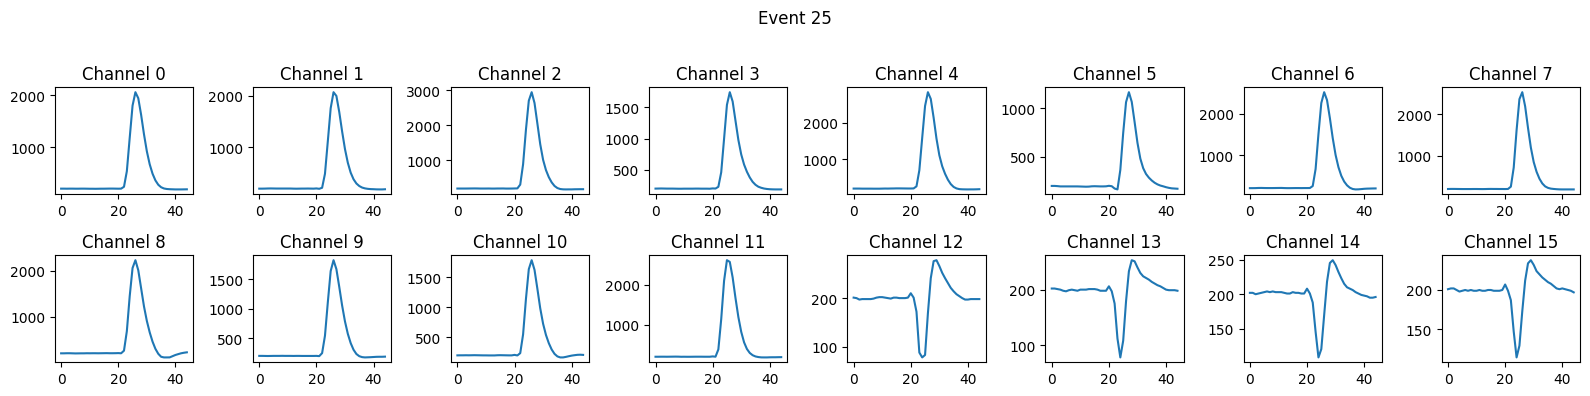

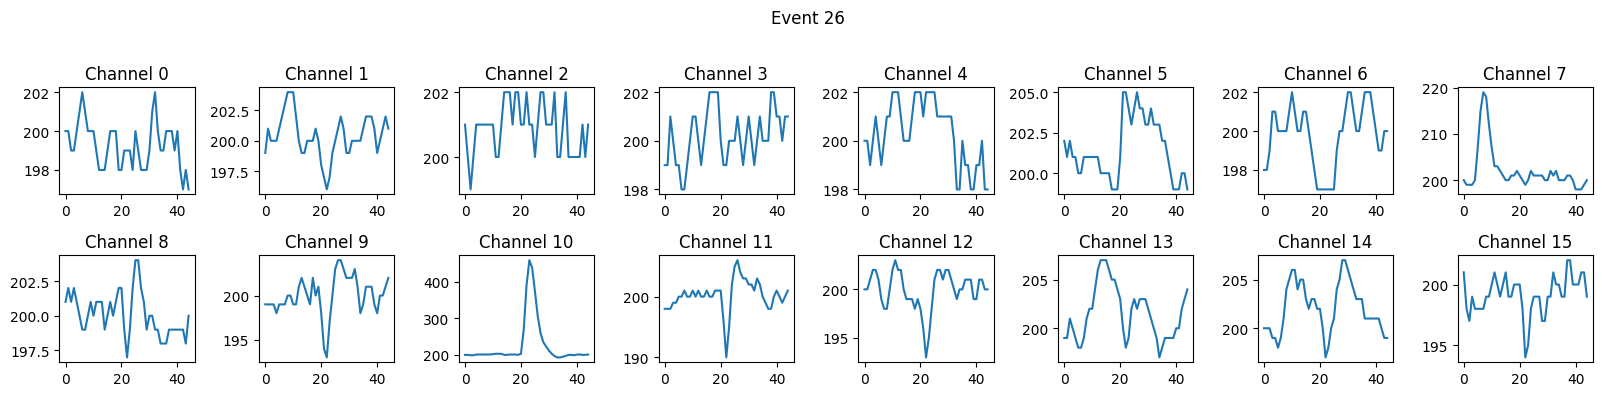

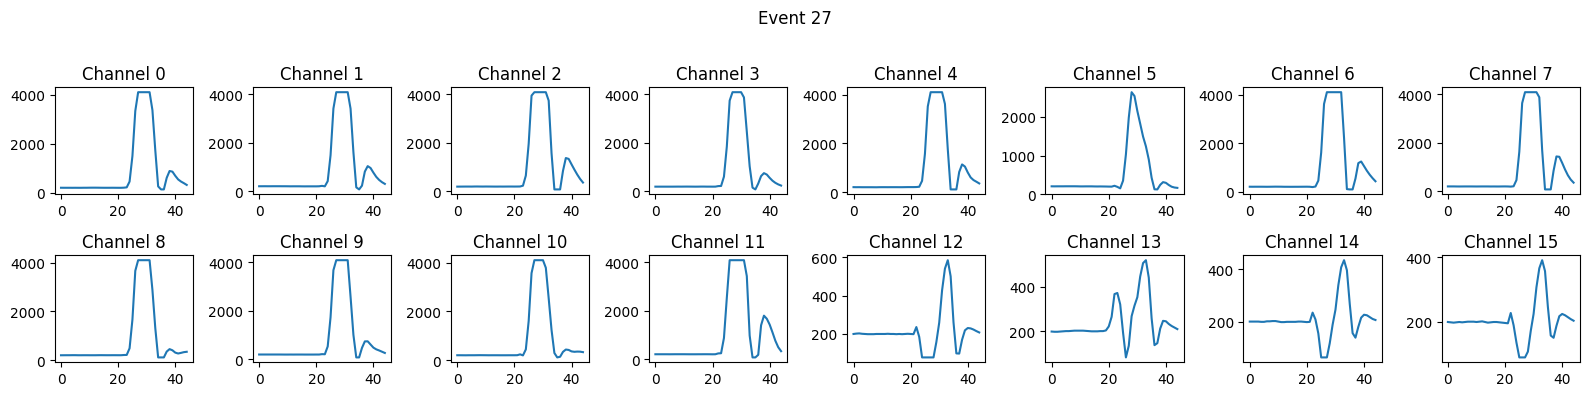

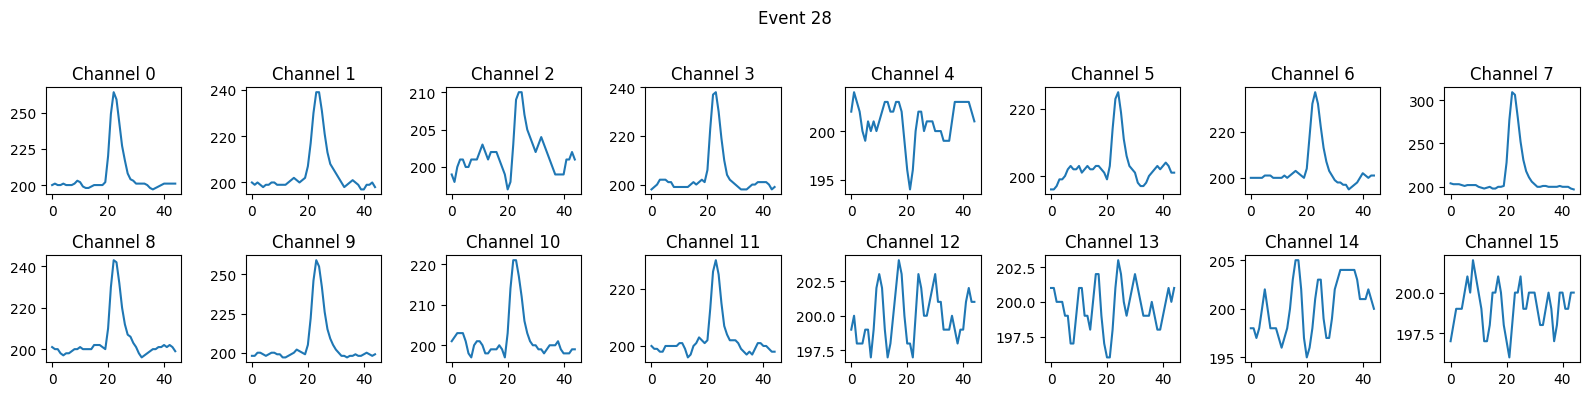

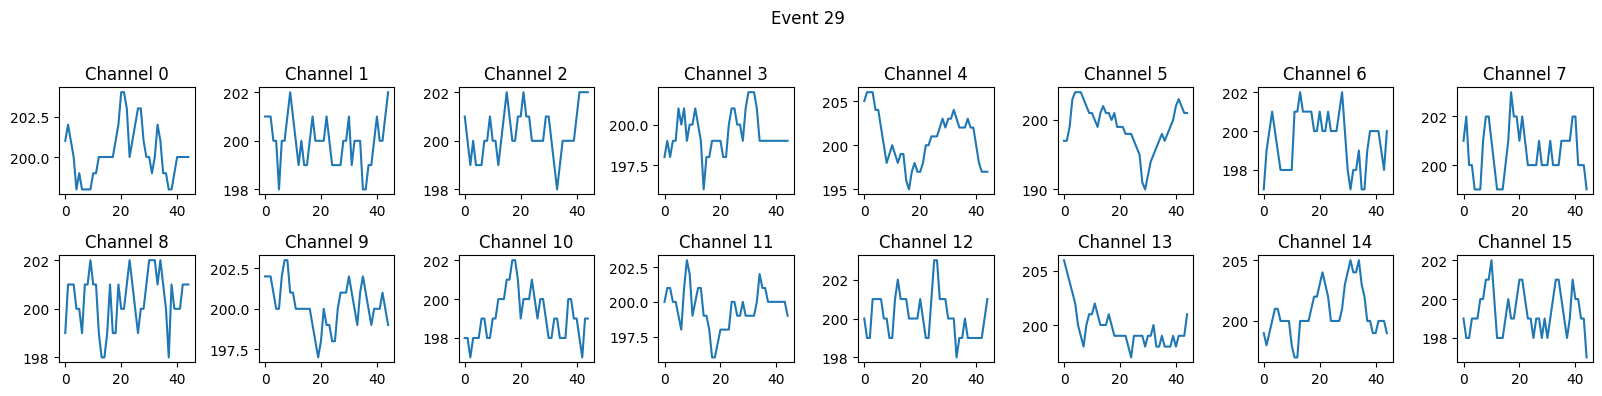

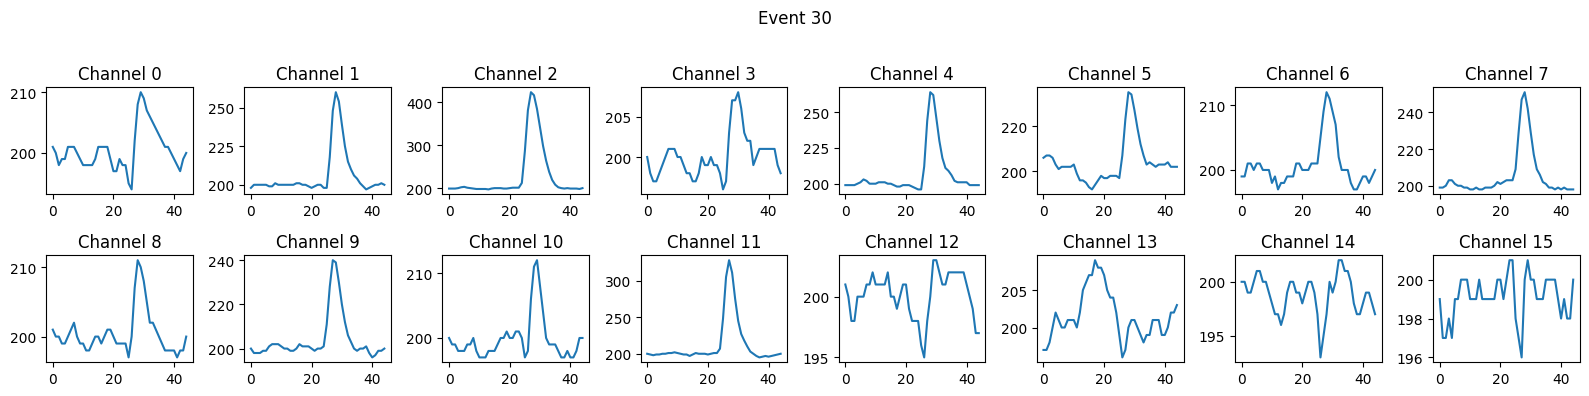

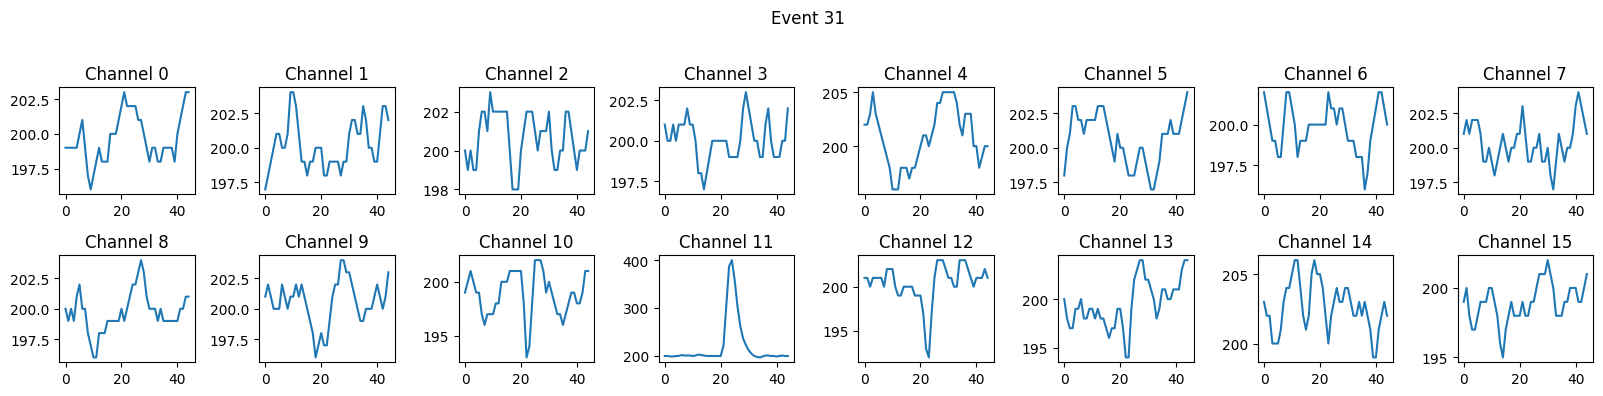

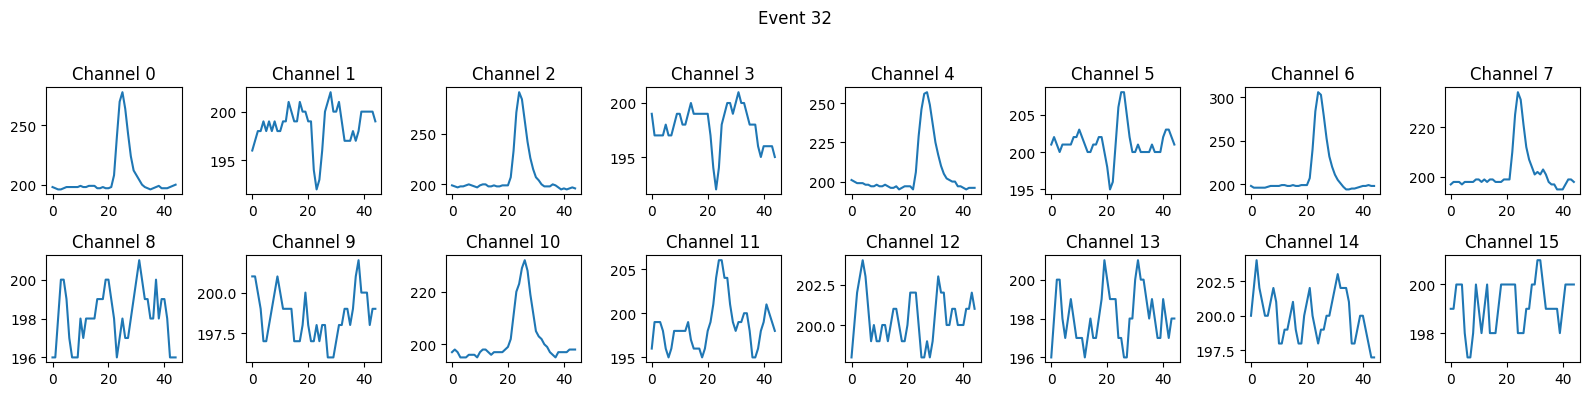

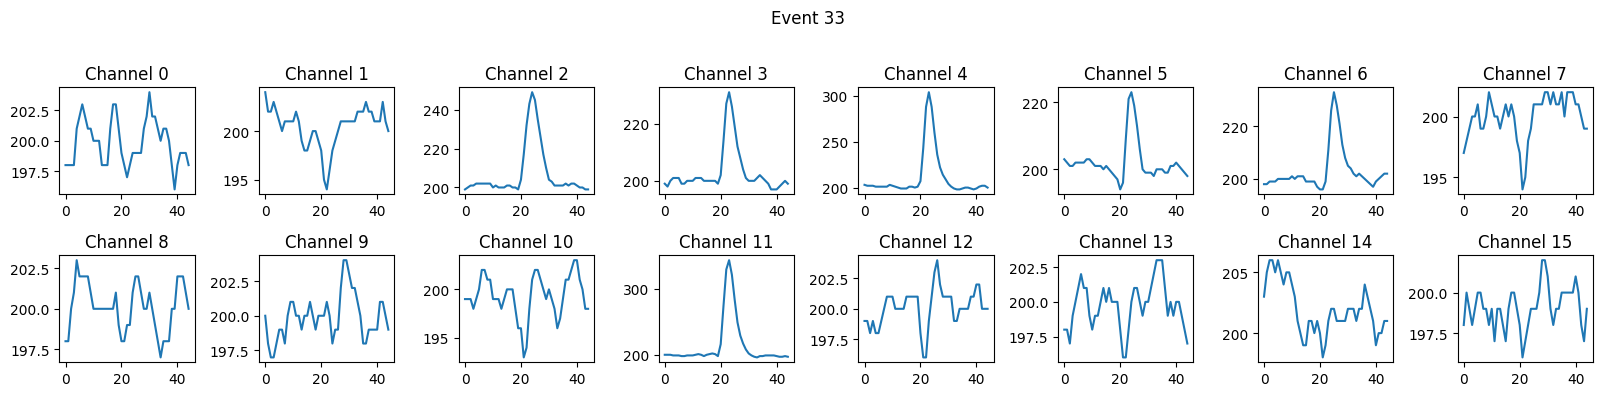

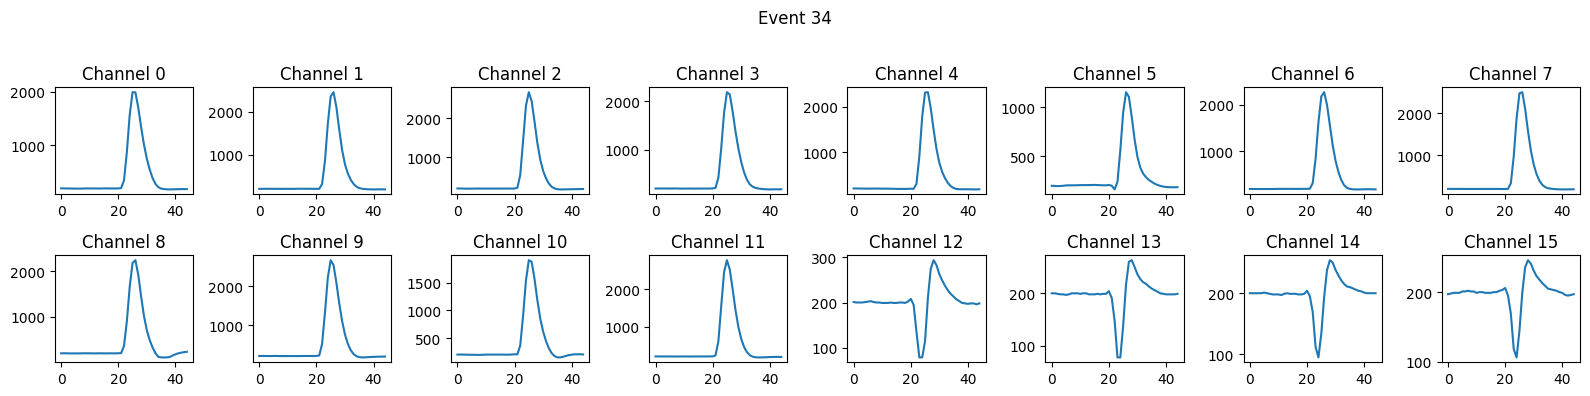

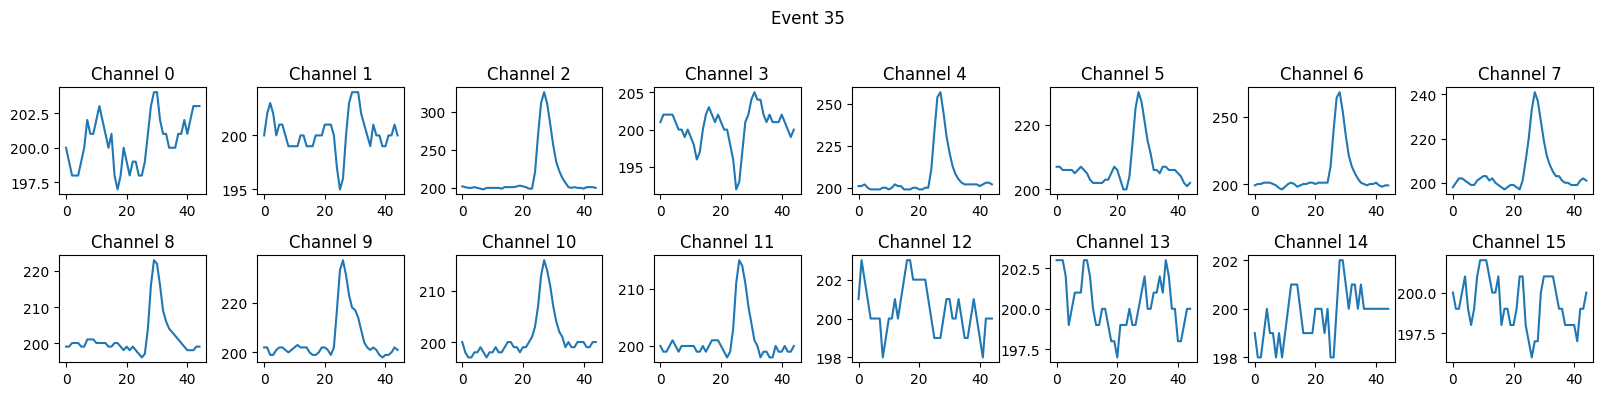

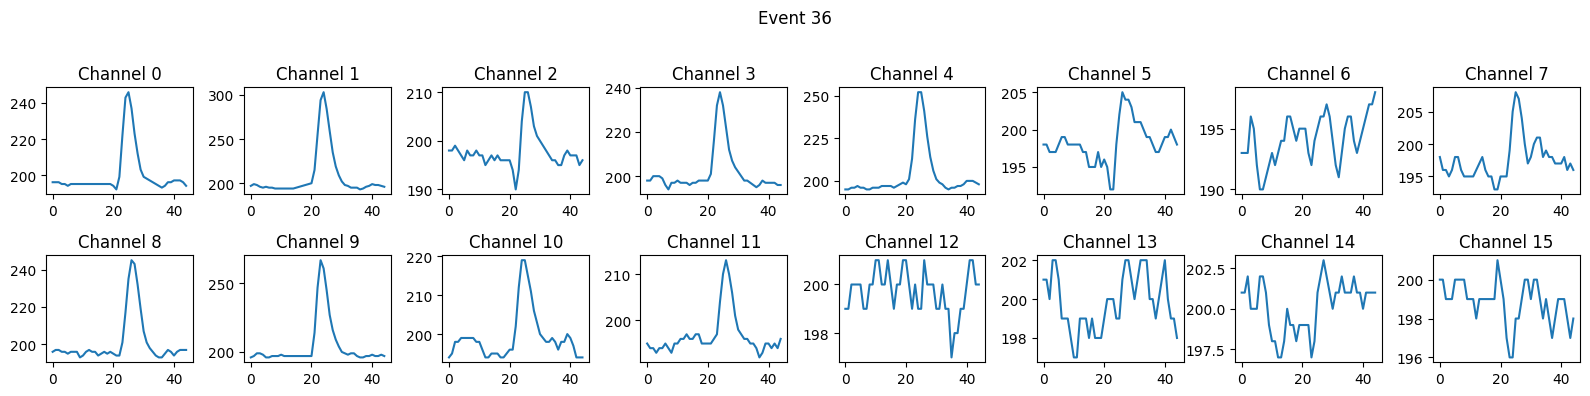

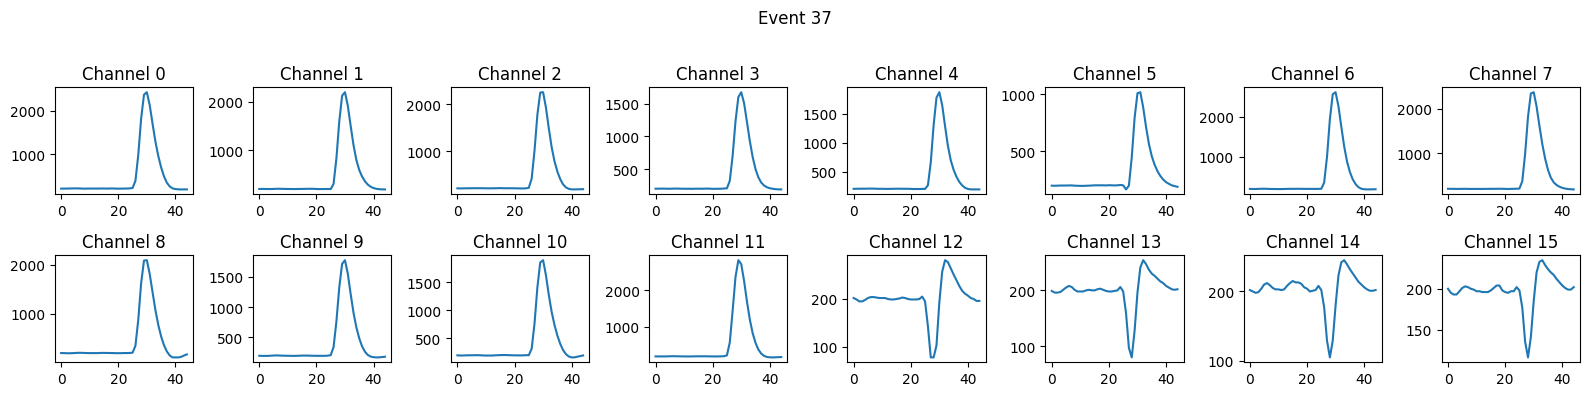

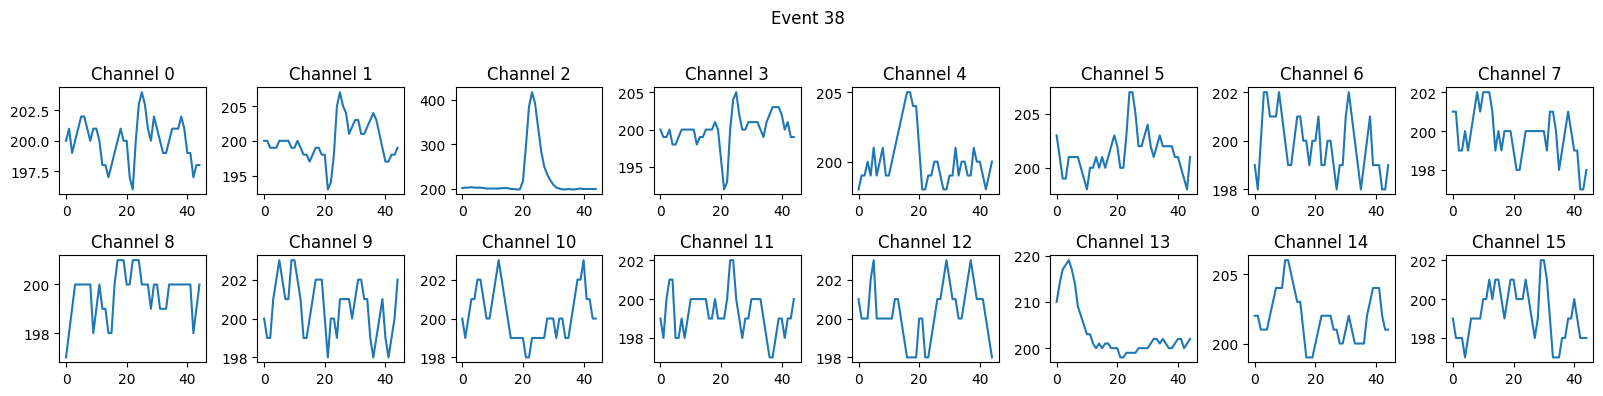

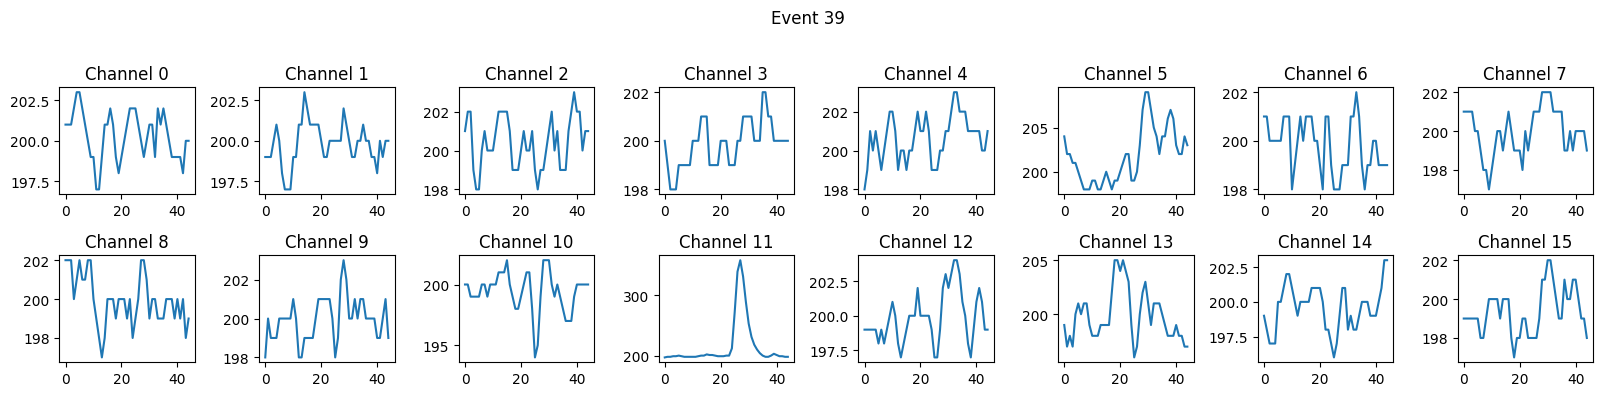

In [6]:
# Plot adcVal for all channels in first 40 events, each event has 16 channels
# Create 40 separate figures, each with 16 subplots in 4x8 arrangement
np.random.seed(42)  
random_nums = np.random.randint(0, 20000, size=40)
print("Randomly selected event indices:", random_nums)
events = data1['adcVal'].array(library='ak')[random_nums]

for i in range(40):
    plt.figure(figsize=(16, 4))  # Create a new figure for each event
    plt.suptitle(f'Event {i}') # Add a title for the whole figure
    
    for ch in range(16):  # 16 channels per event
        plt.subplot(2, 8, ch + 1)  # 2 rows, 8 columns, channel index

        # Corrected line: np.arange instead of np.arrange
        x_vals = np.arange(45) 
        
        plt.plot(x_vals, events[i][ch])
        plt.title(f'Channel {ch}')

    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
    plt.show() # Display the figure for the current event

SiPM channel 13, 14


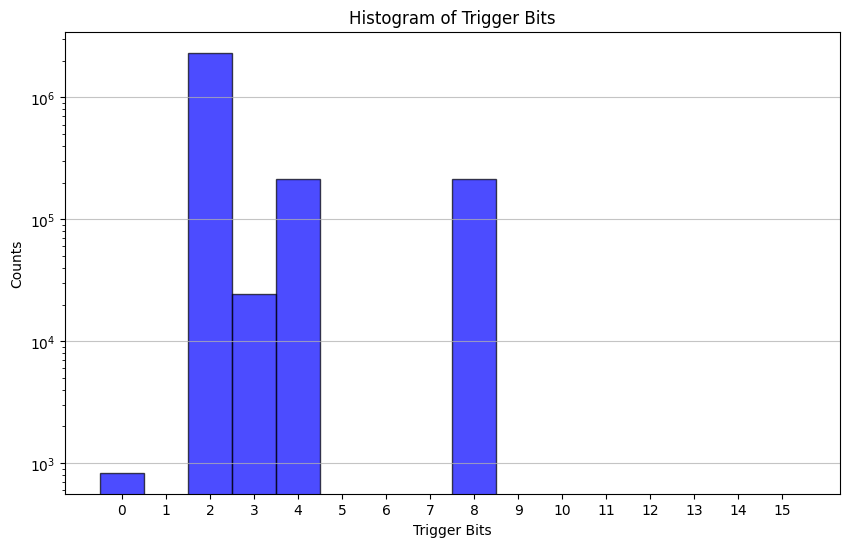

In [12]:
#Plot hist for triggerBits
trigger_bits = data1['triggerBits'].array(library='ak')
plt.figure(figsize=(10, 6))
plt.hist(trigger_bits, bins=np.arange(-0.5, 16.5, 1), alpha=0.7, color='blue', edgecolor='black')
plt.xticks(range(16))
plt.yscale('log')
plt.xlabel('Trigger Bits')
plt.ylabel('Counts')
plt.title('Histogram of Trigger Bits')
plt.grid(axis='y', alpha=0.75)
plt.show()

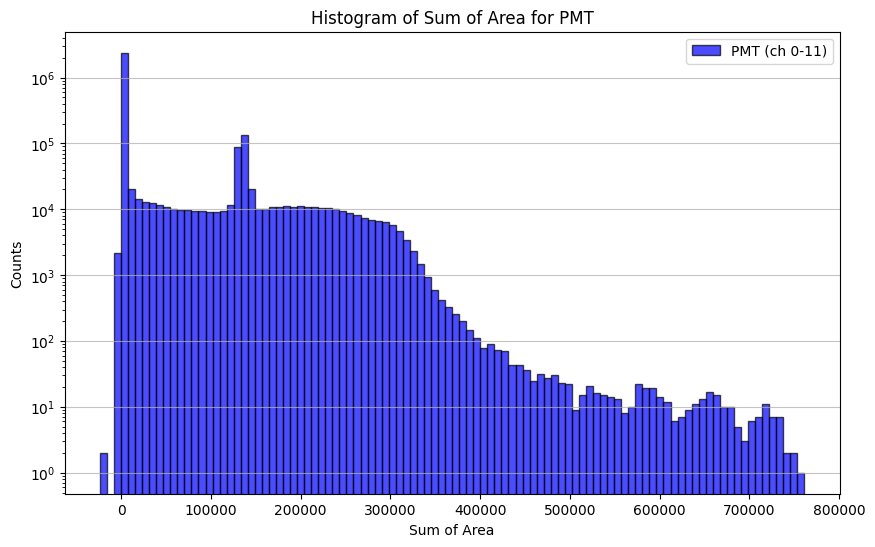

In [14]:
#PMT channel 0-11, SiPM channel 13-14, plot sum of area for PMT and SiPM
SumPMT = np.array(data1['area'].array(library='ak')[:, :12]).sum(axis=1)
plt.figure(figsize=(10, 6))
plt.hist(SumPMT, bins=100, alpha=0.7, label='PMT (ch 0-11)', color='blue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Sum of Area')
plt.ylabel('Counts')
plt.title('Histogram of Sum of Area for PMT')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  

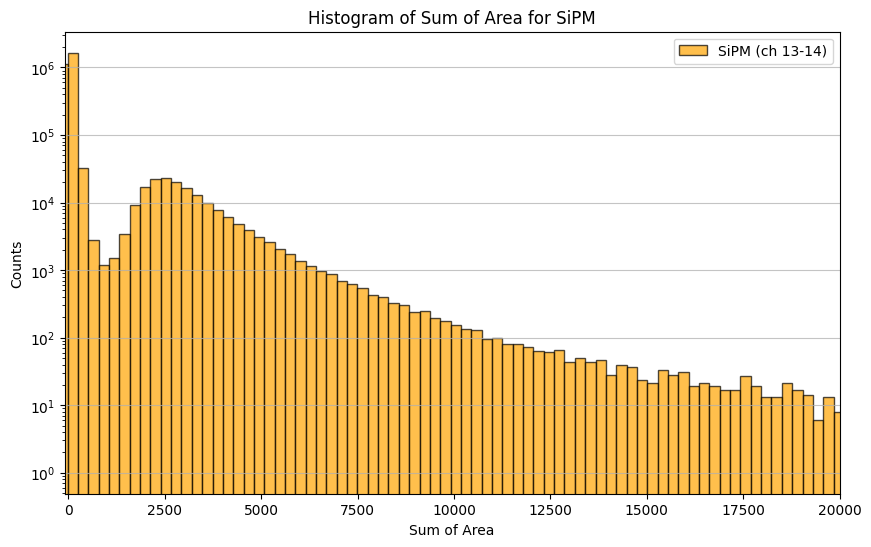

In [18]:
#PMT channel 0-11, SiPM channel 13-14, plot sum of area for PMT and SiPM
SumSiPM = np.array(data1['area'].array(library='ak')[:, 13:15]).sum(axis=1)
plt.figure(figsize=(10, 6))
plt.hist(SumSiPM, bins=400, alpha=0.7, label='SiPM (ch 13-14)', color='orange', edgecolor='black')
plt.yscale('log')
plt.xlim(-100, 20000)
plt.xlabel('Sum of Area')
plt.ylabel('Counts')
plt.title('Histogram of Sum of Area for SiPM')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  

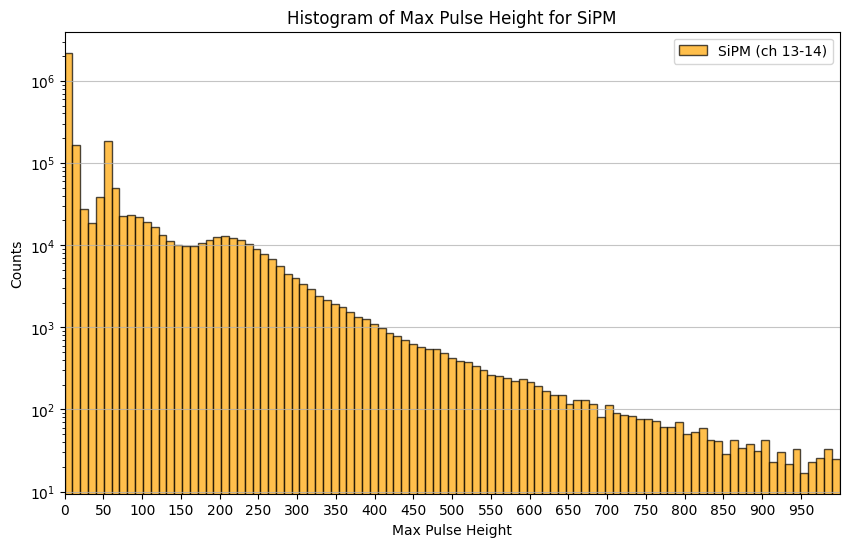

In [26]:
#PMT channel 0-11, SiPM channel 13-14, plot sum of area for PMT and SiPM
SumSiPM = np.array(data1['pulseH'].array(library='ak')[:, 13:15]).max(axis=1)
plt.figure(figsize=(10, 6))
bs = np.linspace(0, 1000, 100)
plt.hist(SumSiPM, bins=bs, alpha=0.7, label='SiPM (ch 13-14)', color='orange', edgecolor='black')
plt.yscale('log')
plt.xlim(0, 1000)
#set x ticks from 0 to 1000 with step of 50
plt.xticks(np.arange(0, 1000, 50))
plt.xlabel('Max Pulse Height')
plt.ylabel('Counts')
plt.title('Histogram of Max Pulse Height for SiPM')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()  